# Induced Seismicity Analysis

Analyze the relationship between injection-rate time series and observed event counts, then detect and inspect major injection peaks.

## 1) Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
from scipy.signal import find_peaks, peak_widths


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.catalogs as catalogs  # trigger catalog registrations
from src.utils.tpp_experiments import load_tpp_catalog
from src.utils.utils import set_seed
from src.utils.viz_sequences import plot_intensity

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
set_seed(0)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf


## 2) Load Catalog

In [2]:
DATASET = 'PNR_1z'
CATALOG_CFG = {
    'freq': '1D',
    'mag_completeness': -1.5,
}


def load_catalog(dataset: str, catalog_cfg: dict):
    catalog_ds, registry_name, _ = load_tpp_catalog(
        dataset,
        base_dir=PROJECT_ROOT / 'data' / dataset,
        catalog_cfg=catalog_cfg,
        candidates=[f'{dataset}-Standard', dataset],
    )
    print(f'Using catalog registry name: {registry_name}')
    return catalog_ds


catalog_ds = load_catalog(DATASET, CATALOG_CFG)
seq = catalog_ds.full_sequence
freq = pd.to_timedelta(catalog_ds.metadata['freq'])

print(f"Dataset: {catalog_ds.metadata.get('name', DATASET)}")
print(f"freq: {catalog_ds.metadata['freq']}")
print(f"start_ts: {catalog_ds.metadata['start_ts']}")
print(f"train_start_ts: {catalog_ds.metadata['train_start_ts']}")
print(f"val_start_ts: {catalog_ds.metadata['val_start_ts']}")
print(f"test_start_ts: {catalog_ds.metadata['test_start_ts']}")

Using catalog registry name: PNR_1z-Standard
Dataset: PNR_1z
freq: 1D
start_ts: 2018-10-15 08:00:00
train_start_ts: 2018-10-22 00:00:00
val_start_ts: 2018-11-22 00:00:00
test_start_ts: 2018-12-14 00:00:00


In [3]:
train_ds = catalog_ds.train
val_ds = catalog_ds.val
test_ds = catalog_ds.test

print('split sizes:')
print(f'- train: {len(train_ds[0])}')
print(f'- val: {len(val_ds[0])}')
print(f'- test: {len(test_ds[0])}')

print('val/test arrival time ranges:')
print(val_ds[0].arrival_times[[0, -1]])
print(test_ds[0].arrival_times[[0, -1]])

split sizes:
- train: 4086
- val: 5290
- test: 6140
val/test arrival time ranges:
tensor([ 1.2314, 59.5789])
tensor([ 1.2314, 64.1675])


## 3) Build Injection and Count Series

In [4]:
# Injection-rate series
injection = seq.time_series.squeeze().detach().cpu().numpy()
inj_time = seq.time_series_times.squeeze().detach().cpu().numpy()

# Event arrival times
arrival_times = seq.arrival_times.detach().cpu().numpy()

# Counts per injection bin
bin_counts, _ = np.histogram(arrival_times, bins=inj_time)

# Midpoints so counts and injection align in shape
injection_mid = 0.5 * (injection[1:] + injection[:-1])
inj_time_mid = 0.5 * (inj_time[1:] + inj_time[:-1])

# Additional event intensity estimate from fixed-width bins
dt_intensity = 1.0 / 60.0
edges = np.arange(0.0, float(arrival_times.max()) + dt_intensity, dt_intensity)
counts_fixed, _ = np.histogram(arrival_times, bins=edges)
lam_fixed = counts_fixed / dt_intensity

print(f'injection shape: {injection.shape}')
print(f'bin_counts shape: {bin_counts.shape}')
print(f'lambda(max) with dt={dt_intensity}: {lam_fixed.max():.3f}')
print(f'indices where lambda > 500: {(np.nonzero(lam_fixed > 500)[0] / 60)[:10]}')

injection shape: (92435,)
bin_counts shape: (92434,)
lambda(max) with dt=0.016666666666666666: 16260.000
indices where lambda > 500: [1.23333333 1.25       1.28333333 2.31666667 2.33333333 2.35
 2.36666667 2.38333333 2.4        2.41666667]


## 4) Global Visualization

<Axes: ylabel='Intensity'>

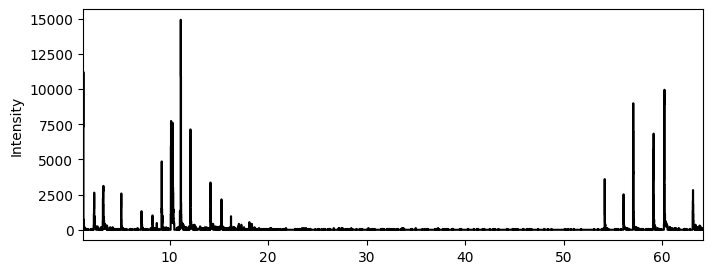

In [5]:
plot_intensity(seq, dt=1 / 60)

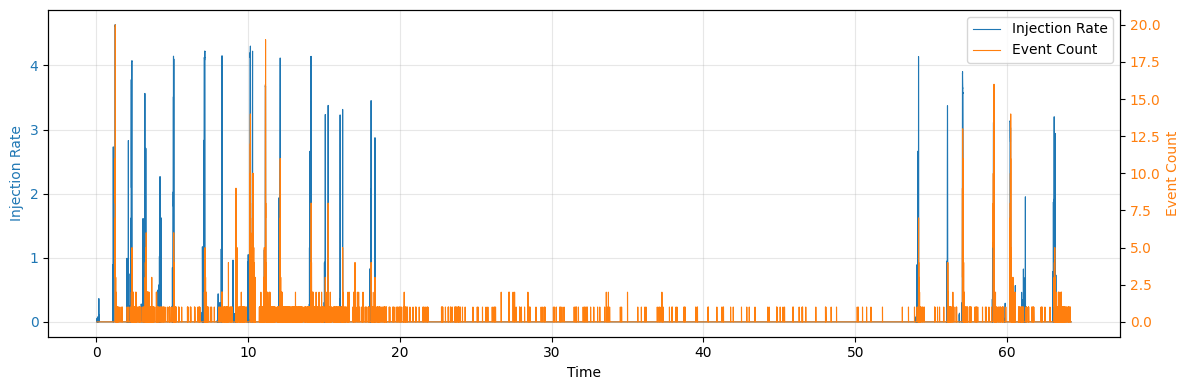

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 4))

line_inj = ax1.plot(inj_time_mid, injection_mid, color='tab:blue', linewidth=0.8, label='Injection Rate')
ax1.set_xlabel('Time')
ax1.set_ylabel('Injection Rate', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
line_cnt = ax2.plot(inj_time_mid, bin_counts, color='tab:orange', linewidth=0.8, label='Event Count')
ax2.set_ylabel('Event Count', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines = line_inj + line_cnt
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc='upper right')

fig.tight_layout()
plt.show()

## 5) Window Analysis

injection sum: 67.0874, count sum: 105.0000, ratio: 1.565122


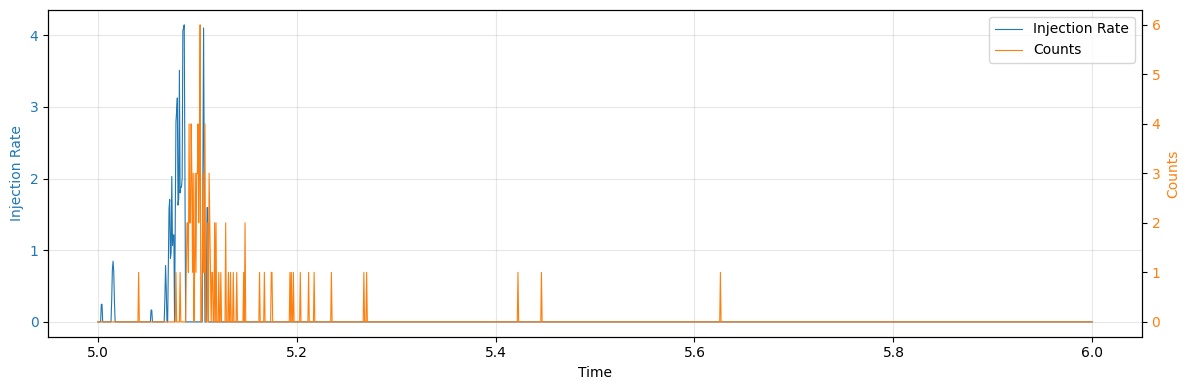

In [7]:
def plot_window(window_start=5.0, window_len=1.0, x=inj_time_mid, injection_series=injection_mid, count_series=bin_counts, figsize=(12, 4), ax=None):
    window_end = window_start + window_len
    mask = (x >= window_start) & (x <= window_end)

    if mask.sum() == 0:
        raise ValueError('Selected window has no data points. Adjust window_start/window_len.')

    if ax is None:
        fig, ax1 = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
        ax1 = ax

    l1 = ax1.plot(x[mask], injection_series[mask], label='Injection Rate', color='tab:blue', linewidth=0.8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Injection Rate', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    l2 = ax2.plot(x[mask], count_series[mask], label='Counts', color='tab:orange', linewidth=0.8)
    ax2.set_ylabel('Counts', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right')

    fig.tight_layout()

    inj_sum = float(injection_series[mask].sum())
    count_sum = float(count_series[mask].sum())
    ratio = count_sum / inj_sum if inj_sum != 0 else float('inf')

    return {
        'fig': fig,
        'ax1': ax1,
        'ax2': ax2,
        'inj_sum': inj_sum,
        'count_sum': count_sum,
        'ratio': ratio,
    }


res = plot_window(window_start=5.0, window_len=1.0)
print(f"injection sum: {res['inj_sum']:.4f}, count sum: {res['count_sum']:.4f}, ratio: {res['ratio']:.6f}")

In [8]:
def to_time_index(absolute_time_str: str) -> float:
    start = pd.to_datetime(catalog_ds.metadata['start_ts'])
    target = pd.to_datetime(absolute_time_str)
    return float((target - start) / freq)


time_examples = [
    '2018-10-17 14:00:00',
    '2018-10-25 13:28:00',
    '2018-10-25 13:55:00',
    '2018-12-14 15:00:00',
]

for s in time_examples:
    print(s, '->', to_time_index(s))

2018-10-17 14:00:00 -> 2.25
2018-10-25 13:28:00 -> 10.227777777777778
2018-10-25 13:55:00 -> 10.246527777777779
2018-12-14 15:00:00 -> 60.291666666666664


## 6) Peak and Base Detection

Found peaks: 60
First 10 peak indices: [1555 1735 2853 2919 2988 3154 3262 3328 4381 4467]
First 10 peak values: [2.730082   4.6337767  0.99134076 0.70635414 2.8295803  0.75
 3.7785392  4.073419   1.6129249  1.5516667 ]
First 10 left bases: [1550 1710 2845 2916 2979 3153 3253 3249 4370 4464]
First 10 right bases: [1561 1751 2857 2921 2992 3156 3280 3340 4385 4469]


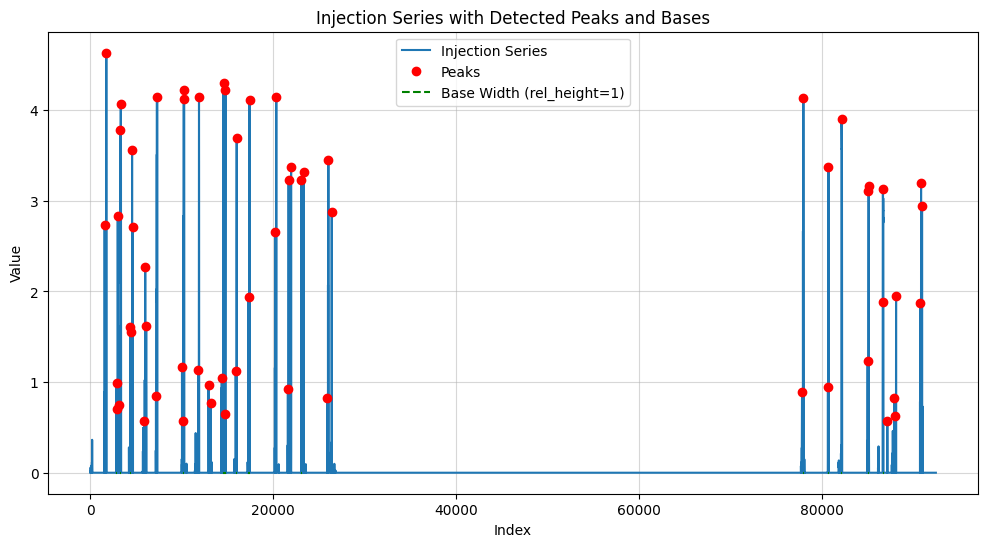

In [9]:
PEAK_HEIGHT = 0.5
PEAK_MIN_DISTANCE = 60

peaks_indices, peak_props = find_peaks(
    injection_mid,
    height=PEAK_HEIGHT,
    distance=PEAK_MIN_DISTANCE,
)

local_maxima_values = injection_mid[peaks_indices]

widths, width_heights, left_bases_float, right_bases_float = peak_widths(
    x=injection_mid,
    peaks=peaks_indices,
    rel_height=1,
)

left_bases = np.round(left_bases_float).astype(int)
right_bases = np.round(right_bases_float).astype(int)

print(f'Found peaks: {len(peaks_indices)}')
print('First 10 peak indices:', peaks_indices[:10])
print('First 10 peak values:', local_maxima_values[:10])
print('First 10 left bases:', left_bases[:10])
print('First 10 right bases:', right_bases[:10])

plt.figure(figsize=(12, 6))
plt.plot(injection_mid, label='Injection Series')
plt.plot(peaks_indices, local_maxima_values, 'o', color='red', label='Peaks')

for i in range(len(peaks_indices)):
    plt.hlines(
        y=width_heights[i],
        xmin=left_bases_float[i],
        xmax=right_bases_float[i],
        color='green',
        linestyle='--',
        label='Base Width (rel_height=1)' if i == 0 else '',
    )

plt.title('Injection Series with Detected Peaks and Bases')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

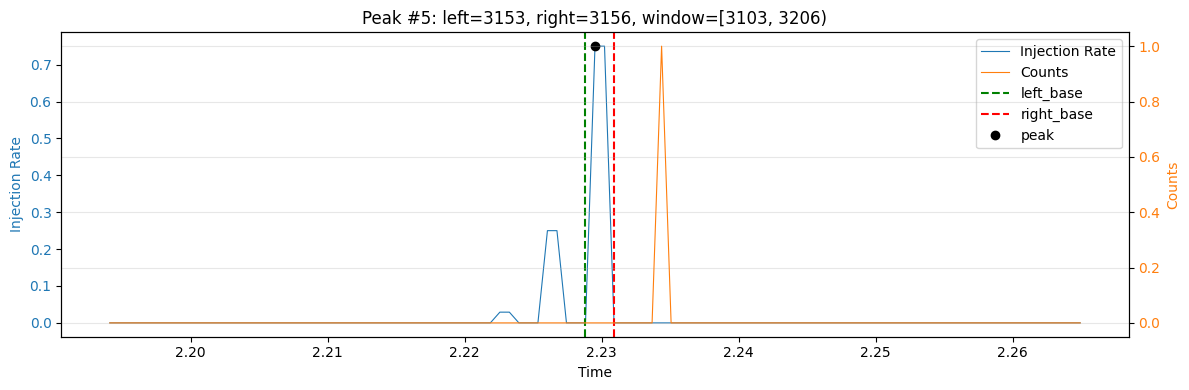

In [10]:
def plot_peak_window(index=5, offset=50, x=inj_time_mid, injection_series=injection_mid, count_series=bin_counts, peaks=peaks_indices, left=left_bases, right=right_bases):
    if index < 0 or index >= len(left):
        raise IndexError(f'index {index} out of range (0..{len(left)-1})')

    lb = int(left[index])
    rb = int(right[index])
    start = max(0, lb - offset)
    end = min(len(injection_series), rb + offset)

    x_win = x[start:end]
    inj_win = injection_series[start:end]
    cnt_win = count_series[start:end]

    fig, ax1 = plt.subplots(figsize=(12, 4))
    l1 = ax1.plot(x_win, inj_win, color='tab:blue', label='Injection Rate', linewidth=0.8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Injection Rate', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    l2 = ax2.plot(x_win, cnt_win, color='tab:orange', label='Counts', linewidth=0.8)
    ax2.set_ylabel('Counts', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    ax1.axvline(x[lb], color='green', linestyle='--', label='left_base')
    ax1.axvline(x[rb], color='red', linestyle='--', label='right_base')

    peak_idx = int(peaks[index])
    if start <= peak_idx < end:
        ax1.plot(x[peak_idx], injection_series[peak_idx], 'o', color='black', label='peak')

    lines = l1 + l2 + ax1.lines[-3:]
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc='upper right')

    plt.title(f'Peak #{index}: left={lb}, right={rb}, window=[{start}, {end})')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_peak_window(index=5, offset=50)